In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]

## Data Loading

We will traverse the `Results` directory to find all `roofline.json` files and the corresponding raw data files (`pre`).

In [2]:
def load_roofline_json(filepath):
    with open(filepath, 'r') as f:
        data = json.load(f)
    return data

def parse_pre_file(filepath):
    # Columns based on preprocess.py output:
    # wkey, tkey, msec_min, msec_med, msec_max, GB_sec_min, GB_sec_med, GB_sec_max, GFLOP_sec_min, GFLOP_sec_med, GFLOP_sec_max
    columns = [
        'wkey', 'tkey', 
        'msec_min', 'msec_med', 'msec_max', 
        'GB_sec_min', 'GB_sec_med', 'GB_sec_max', 
        'GFLOP_sec_min', 'GFLOP_sec_med', 'GFLOP_sec_max'
    ]
    
    # The pre file might have sections for different precisions, but usually it's just one block for the run.
    # However, preprocess.py prints the precision name first.
    # Let's read it and skip non-numeric lines or handle them.
    
    data = []
    current_precision = None
    
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            if len(parts) == 1 and not parts[0][0].isdigit():
                current_precision = parts[0]
                continue
            
            if len(parts) >= len(columns):
                # Assuming the last columns match
                try:
                    row = [float(x) for x in parts[:len(columns)]]
                    data.append([current_precision] + row)
                except ValueError:
                    continue
                    
    df = pd.DataFrame(data, columns=['precision'] + columns)
    return df

root_dir = "."
machines = []
roofline_data = []
raw_data = {}

for machine in os.listdir(root_dir):
    machine_path = os.path.join(root_dir, machine)
    if not os.path.isdir(machine_path) or machine.startswith('.'):
        continue
        
    # Look for Runs
    for run in os.listdir(machine_path):
        run_path = os.path.join(machine_path, run)
        if not os.path.isdir(run_path) or not run.startswith("Run"):
            continue
            
        # Check for roofline.json
        json_path = os.path.join(run_path, "roofline.json")
        if os.path.exists(json_path):
            try:
                rdata = load_roofline_json(json_path)
                rdata['machine'] = machine
                rdata['run'] = run
                roofline_data.append(rdata)
                
                # Look for raw data in FLOPS.XXX/OpenMP.XXX/pre
                # We need to find where the 'pre' files are.
                # Usually in FLOPS.XXX/OpenMP.XXX/
                
                for item in os.listdir(run_path):
                    if item.startswith("FLOPS"):
                        flops_path = os.path.join(run_path, item)
                        if os.path.isdir(flops_path):
                            for subitem in os.listdir(flops_path):
                                if subitem.startswith("OpenMP") or subitem.startswith("MPI"):
                                    raw_path = os.path.join(flops_path, subitem, "pre")
                                    if os.path.exists(raw_path):
                                        df = parse_pre_file(raw_path)
                                        key = f"{machine}/{run}/{item}/{subitem}"
                                        raw_data[key] = df
            except Exception as e:
                print(f"Error loading {json_path}: {e}")

print(f"Loaded {len(roofline_data)} roofline summaries.")
print(f"Loaded {len(raw_data)} raw data files.")

Loaded 5 roofline summaries.
Loaded 90 raw data files.


## Device specific constants
Here we define some constants for each processor, namely the different cache sizes, to plot them in some of the plots as reference points.

In [3]:
caches = {
    "8250U": [32*1024, 256*1024, 6*1024*1024],
    "1600X": [32*1024, 512*1024, 8*1024*1024, 16*1024*1024],
    "5500U": [32*1024, 512*1024, 4*1024*1024, 8*1024*1024],
    "7800X3D": [32*1024, 1*1024*1024, 96*1024*1024],
    "Raspi": [32*1024, 1*1024*1024]
}

,machine,run,max_gflops,L1,L2,L3,L4,L5,L6,DRAM
0,8250U,Run.001,100.90,540.97,371.62,228.83,35.30,29.98,24.07,17.79
1,1600X,Run.002,157.07,916.64,57.18,44.33,NaN,NaN,NaN,33.37
2,7800X3D,Run.001,734.08,2981.19,2097.49,NaN,NaN,NaN,NaN,60.69
3,5500U,Run.001,365.19,1532.88,47.32,35.57,NaN,NaN,NaN,26.48
4,Raspi,Run.001,12.98,103.84,31.50,4.55,3.64,3.06,NaN,2.27


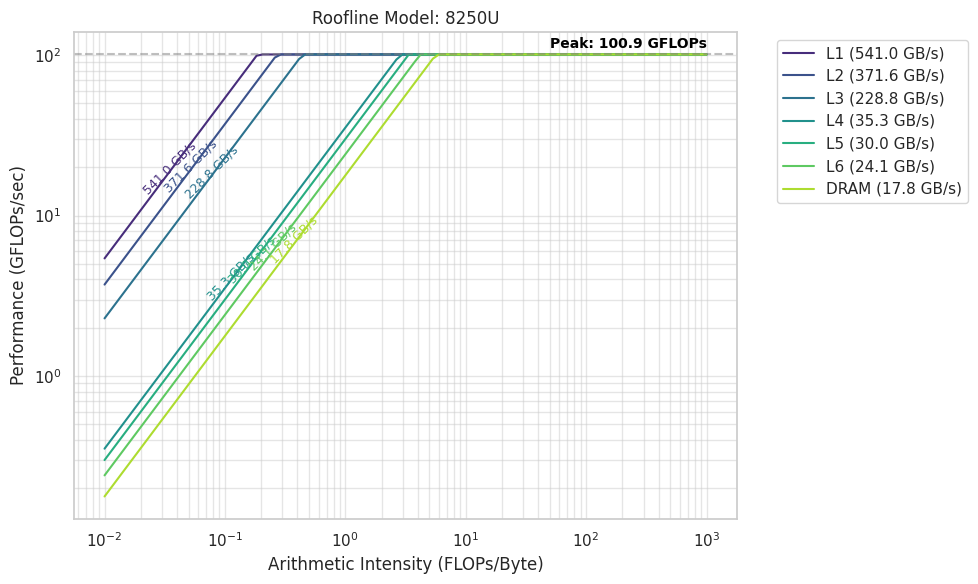

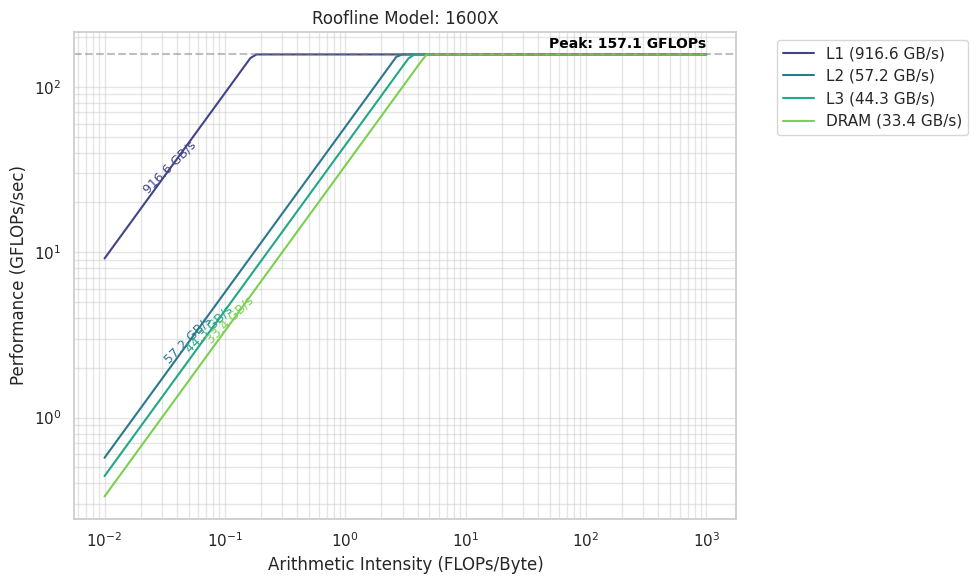

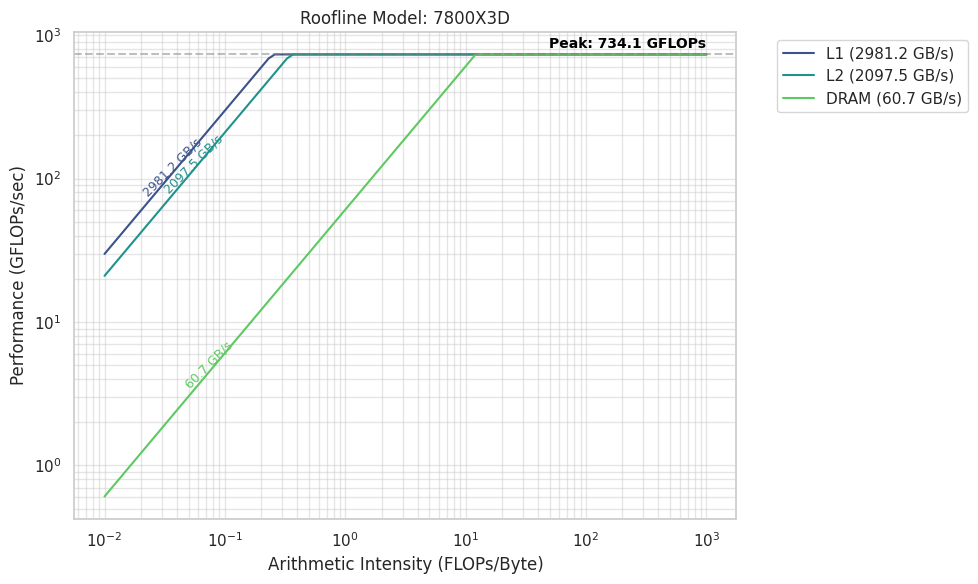

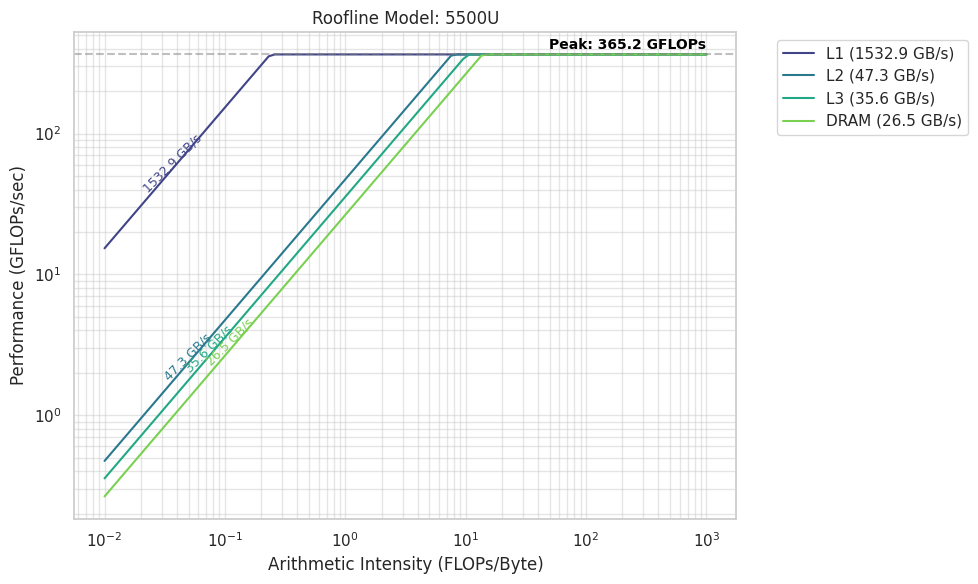

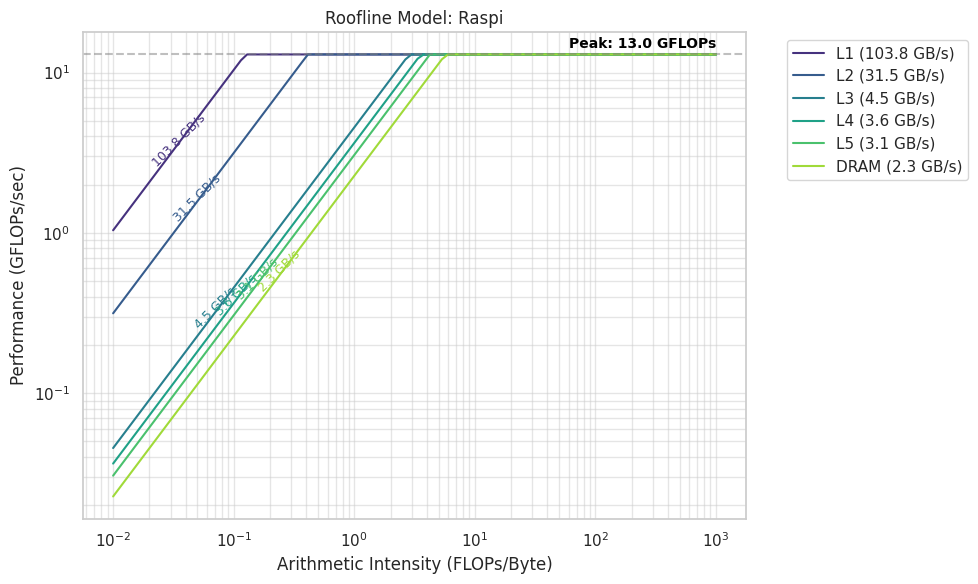

In [4]:
# Extract Roofline Summary
summary_list = []

for entry in roofline_data:
    machine = entry['machine']
    run = entry['run']
    
    # Extract GFLOPs
    gflops_data = entry['empirical']['gflops']['data']
    max_gflops = 0
    for label, value in gflops_data:
        if "GFLOPs" in label:
            max_gflops = max(max_gflops, value)
            
    # Extract Bandwidths
    gbytes_data = entry['empirical']['gbytes']['data']
    bandwidths = {}
    for label, value in gbytes_data:
        bandwidths[label] = value
        
    summary_list.append({
        'machine': machine,
        'run': run,
        'max_gflops': max_gflops,
        **bandwidths
    })

summary_df = pd.DataFrame(summary_list)
display(summary_df)

# Plot Rooflines
def plot_roofline(ax, machine_name, gflops, bandwidths):
    # Create points for the roofline
    # x-axis: Arithmetic Intensity (FLOPs/Byte)
    # y-axis: Performance (GFLOPs/sec)
    
    # Define a range of AI
    ai_min = 0.01
    ai_max = 1000
    ai_points = np.logspace(np.log10(ai_min), np.log10(ai_max), 100)
    
    # Memory Bound: Performance = Bandwidth * AI
    # Compute Bound: Performance = Peak GFLOPs
    
    # We have multiple bandwidths (L1, L2, DRAM, etc.)
    # The roofline is the minimum of (Peak GFLOPs, Bandwidth * AI) for each bandwidth
    
    # Plot each memory level
    colors = sns.color_palette("viridis", len(bandwidths))
    for i, (mem_name, bw) in enumerate(bandwidths.items()):
        y_points = np.minimum(gflops, bw * ai_points)
        ax.plot(ai_points, y_points, label=f"{mem_name} ({bw:.1f} GB/s)", color=colors[i])
        
        # Annotation for Bandwidth
        # Place it at low AI where the line is diagonal
        ann_ai = 0.02 * (1.5 ** i) # Stagger slightly
        if bw * ann_ai < gflops:
             ax.annotate(f"{bw:.1f} GB/s", xy=(ann_ai, bw * ann_ai), 
                         xytext=(ann_ai, bw * ann_ai * 1.2),
                         rotation=45, color=colors[i], fontsize=9, ha='left', va='bottom')

    # Annotation for Peak GFLOPs
    ax.axhline(y=gflops, color='gray', linestyle='--', alpha=0.5)
    ax.annotate(f"Peak: {gflops:.1f} GFLOPs", xy=(ai_max, gflops), 
                xytext=(ai_max, gflops * 1.1),
                color='black', fontsize=10, fontweight='bold', ha='right')
        
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Arithmetic Intensity (FLOPs/Byte)')
    ax.set_ylabel('Performance (GFLOPs/sec)')
    ax.set_title(f'Roofline Model: {machine_name}')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, which="both", ls="-", alpha=0.5)

# Plot for each unique machine (taking the best run)
unique_machines = summary_df['machine'].unique()

for machine in unique_machines:
    machine_runs = summary_df[summary_df['machine'] == machine]
    # Pick the run with highest GFLOPs
    best_run = machine_runs.loc[machine_runs['max_gflops'].idxmax()]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Extract bandwidths from the row (excluding machine, run, max_gflops)
    bws = {k: v for k, v in best_run.items() if k not in ['machine', 'run', 'max_gflops'] and not pd.isna(v)}
    
    plot_roofline(ax, machine, best_run['max_gflops'], bws)
    plt.tight_layout()
    plt.show()

## Deep Dive: Memory Hierarchy Analysis
We analyze the raw bandwidth data to visualize the memory hierarchy. By plotting Bandwidth vs. Working Set Size, we can clearly see the transitions between L1, L2, L3 caches and DRAM.

**Working Set Size (WSS)**: This represents the total amount of memory (in bytes) accessed by all threads during the benchmark kernel execution. It is calculated as:
$$ \text{WSS} = \text{Number of Elements} \times \text{Size of Element} \times \text{Number of Threads} $$
As the WSS increases, it exceeds the capacity of smaller, faster caches (L1, L2), forcing the processor to fetch data from larger, slower memory levels (L3, DRAM), resulting in a drop in bandwidth.

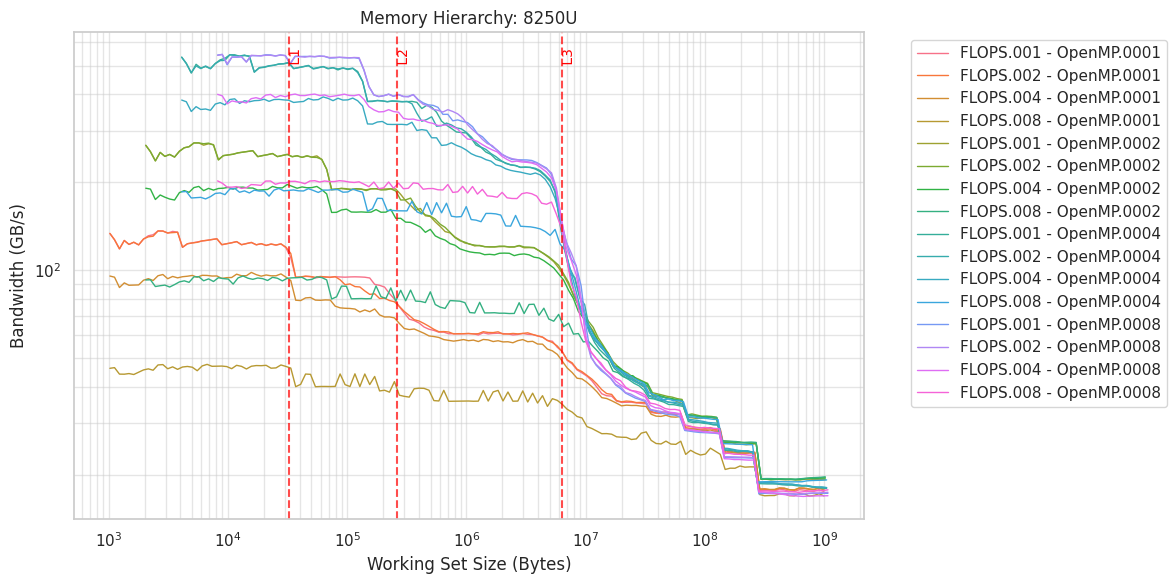

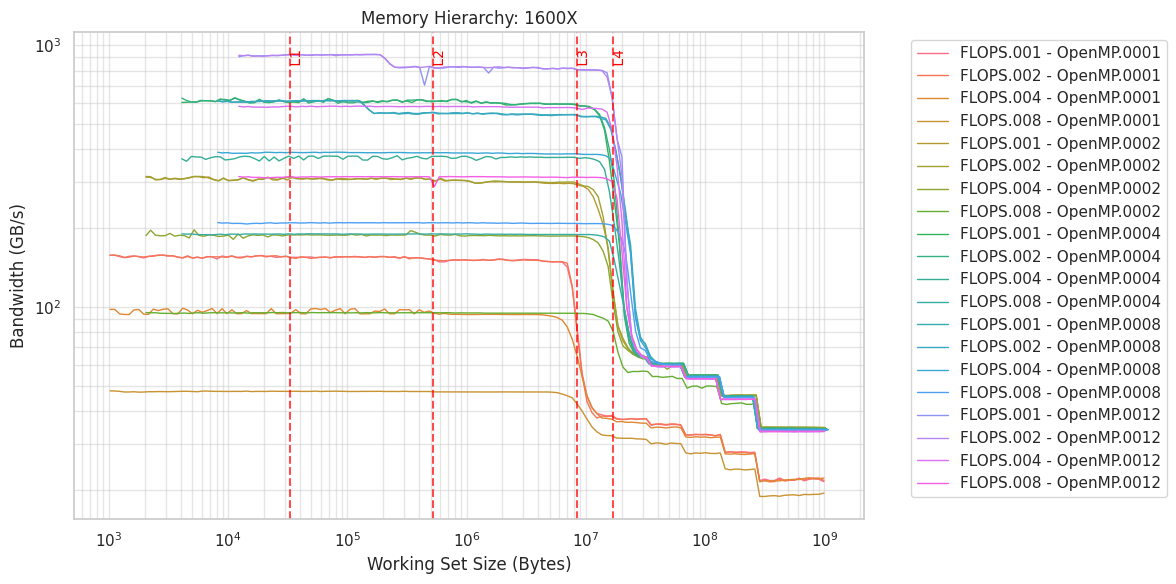

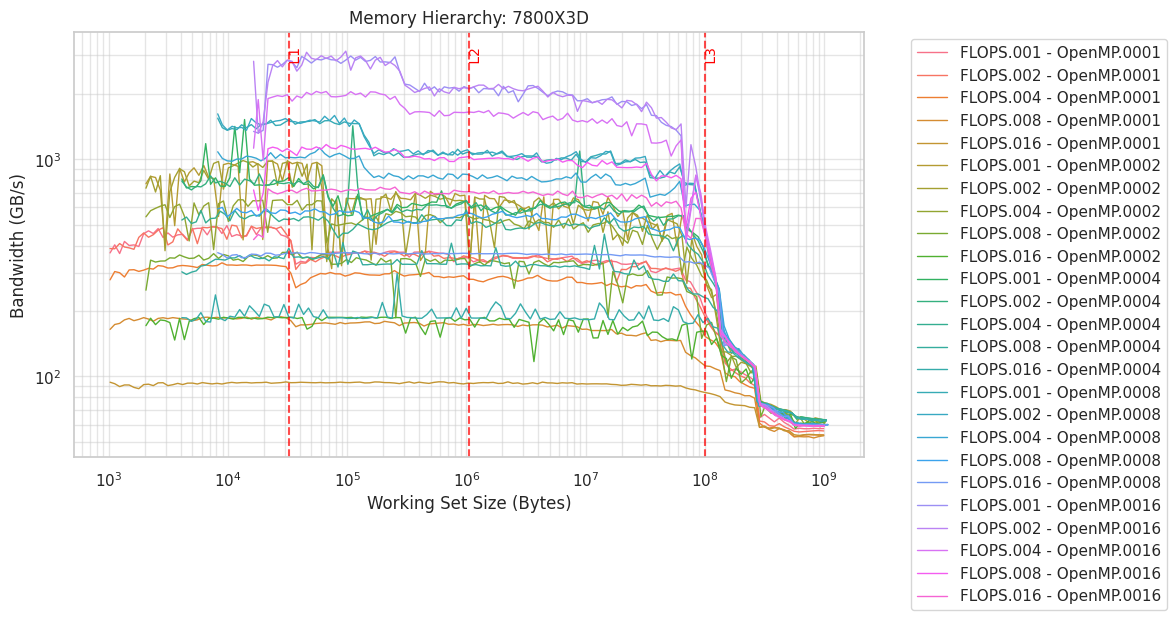

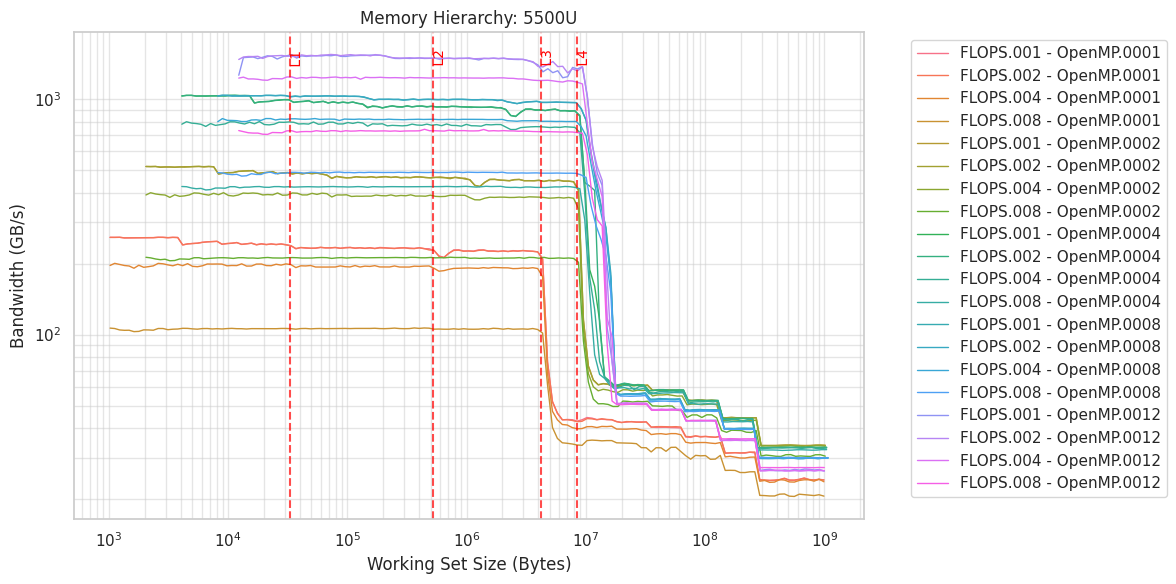

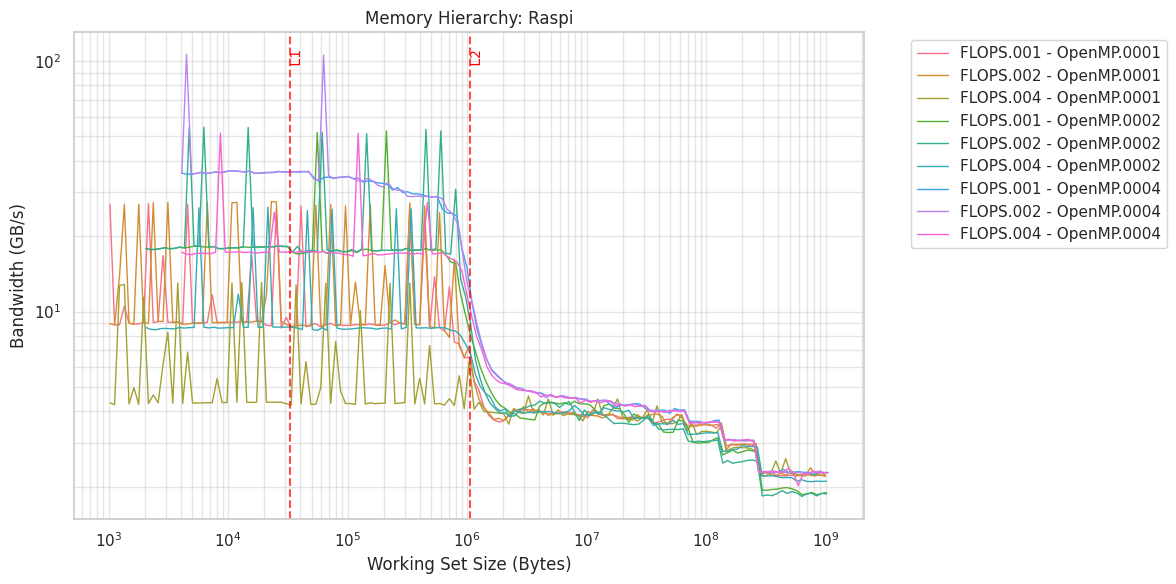

In [27]:
def plot_bandwidth_hierarchy(machine_name, run_name):
    # Filter raw data for this machine and run
    keys = [k for k in raw_data.keys() if k.startswith(f"{machine_name}/{run_name}/")]
    
    if not keys:
        print(f"No raw data found for {machine_name}/{run_name}")
        return

    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Sort keys by OpenMP/MPI count first, then FLOPS
    def sort_key(k):
        parts = k.split('/')
        # parts[2] is FLOPS.XXX, parts[3] is OpenMP.XXX/MPI.XXX
        # We try to extract the number for correct numerical sorting
        try:
            # Extract number after the dot
            p3_val = int(parts[3].split('.')[-1])
        except ValueError:
            p3_val = parts[3]
            
        try:
            p2_val = int(parts[2].split('.')[-1])
        except ValueError:
            p2_val = parts[2]
            
        return (p3_val, p2_val)
        
    keys.sort(key=sort_key)
    
    colors = sns.color_palette("husl", int(len(keys)*1.1))
    
    for i, key in enumerate(keys):
        df = raw_data[key]
        # The key format is machine/run/FLOPS.XXX/OpenMP.XXX
        parts = key.split('/')
        label = f"{parts[2]} - {parts[3]}"
        
        # We want to plot Bandwidth (GB_sec_med) vs Working Set Size (wkey)
        # We aggregate by wkey, taking the max bandwidth across different tkeys (trials)
        # Usually, for a given wkey, we want the best performance achieved.
        
        # Group by wkey and take max of GB_sec_med
        best_bw = df.groupby('wkey')['GB_sec_med'].max().reset_index()
        
        ax.plot(best_bw['wkey'], best_bw['GB_sec_med'], label=label, color=colors[i], linewidth=1)
        
    # Add cache lines
    if machine_name in caches:
        ymin, ymax = ax.get_ylim()
        for i, cache_size in enumerate(caches[machine_name]):
            ax.axvline(x=cache_size, color='red', linestyle='--', alpha=0.7)
            ax.text(cache_size, ymax, f' L{i+1}', rotation=90, verticalalignment='top', color='red', fontsize=10)

    ax.set_xscale('log')#, base=2)
    ax.set_yscale('log')
    ax.set_xlabel('Working Set Size (Bytes)')
    ax.set_ylabel('Bandwidth (GB/s)')
    ax.set_title(f'Memory Hierarchy: {machine_name}')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    #ax.legend(loc='upper right')
    ax.grid(True, which="both", ls="-", alpha=0.5)
    plt.tight_layout()
    plt.show()

# Plot for each unique machine (using the best run identified earlier)
for machine in unique_machines:
    machine_runs = summary_df[summary_df['machine'] == machine]
    best_run_id = machine_runs.loc[machine_runs['max_gflops'].idxmax()]['run']
    plot_bandwidth_hierarchy(machine, best_run_id)

## Deep Dive: Stability Analysis
We analyze the execution time vs. the number of trials/iterations (`tkey`). In a stable system, the execution time should scale linearly with the number of iterations. Deviations might indicate overhead, throttling, or timer resolution issues.

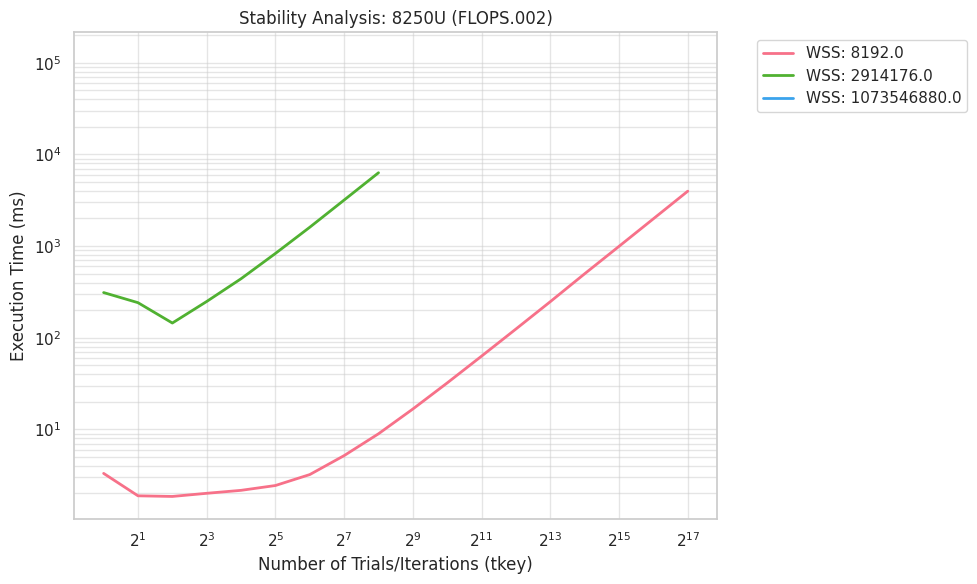

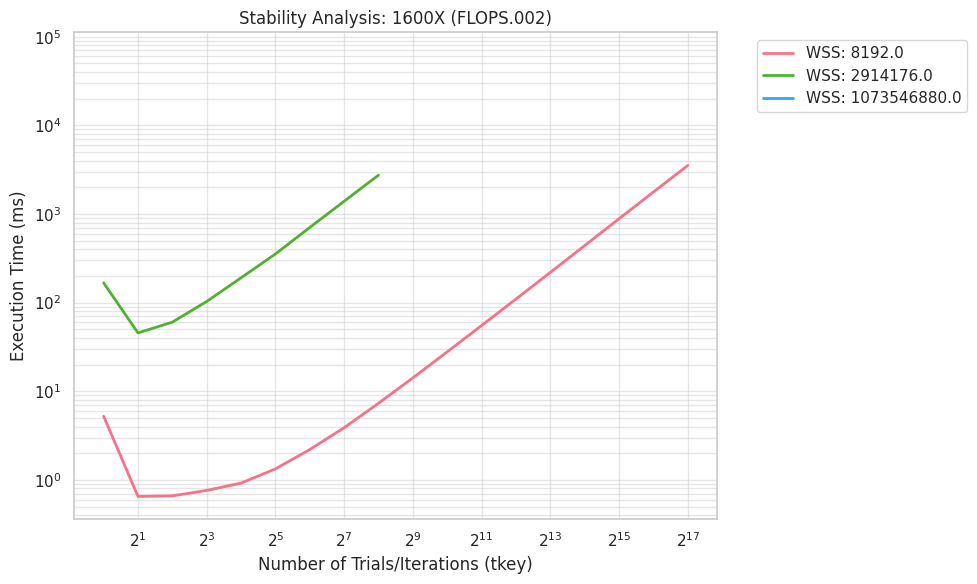

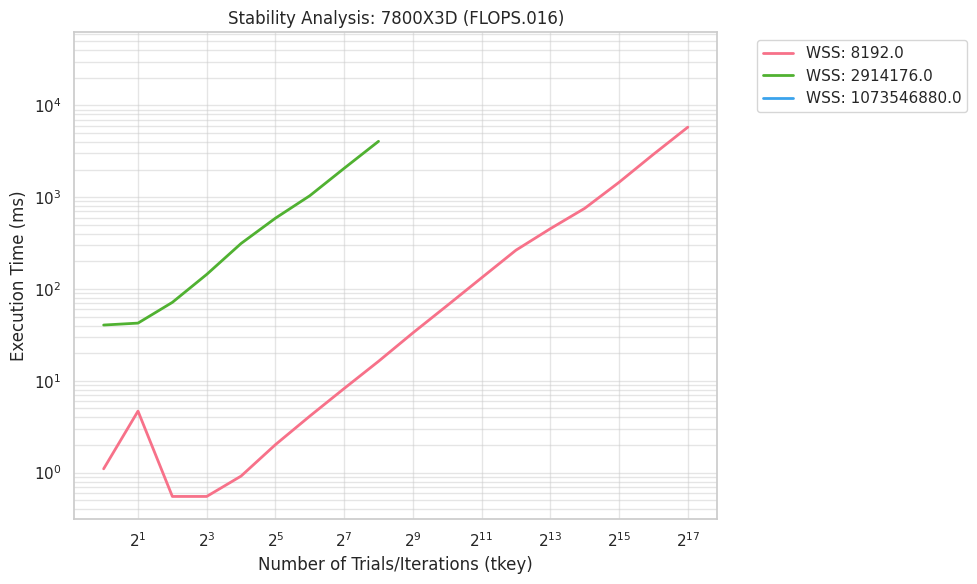

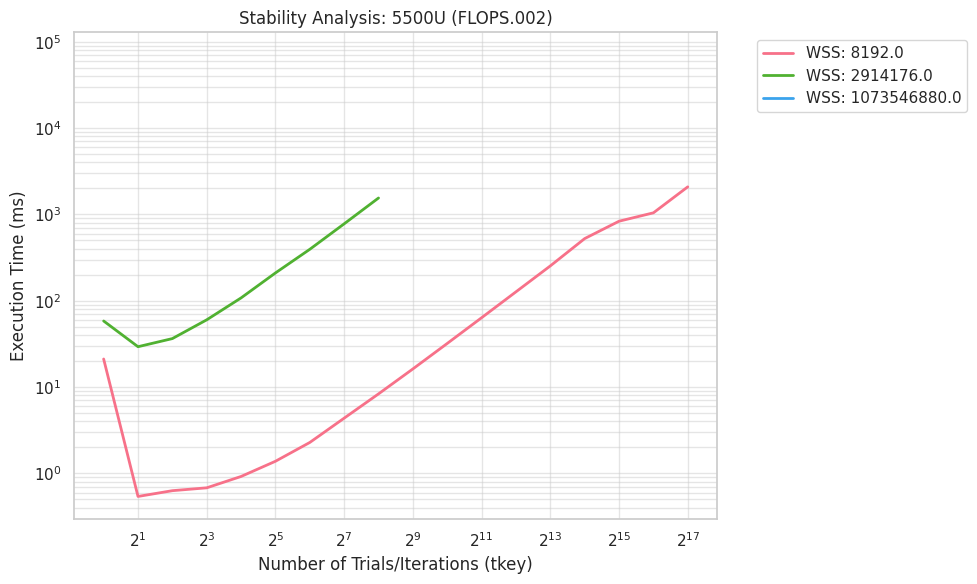

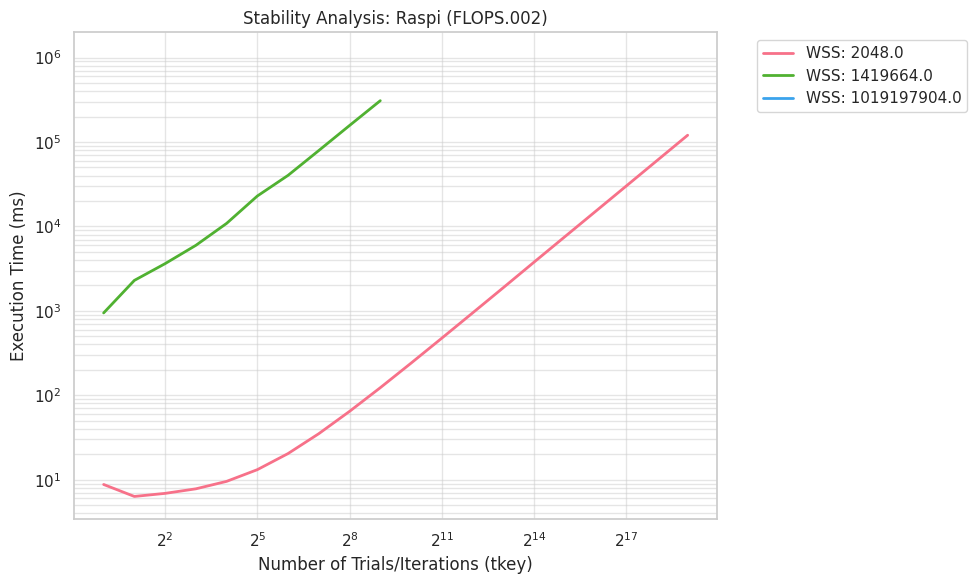

In [6]:
def plot_stability(machine_name, run_name):
    # Filter raw data for this machine and run
    keys = [k for k in raw_data.keys() if k.startswith(f"{machine_name}/{run_name}/")]
    
    if not keys:
        return

    # Pick one dataset (e.g., the first one)
    key = keys[0]
    df = raw_data[key]
    
    # Pick a few working set sizes (small, medium, large)
    wkeys = sorted(df['wkey'].unique())
    if not wkeys:
        return
        
    selected_wkeys = [wkeys[0], wkeys[len(wkeys)//2], wkeys[-1]]
    colors = sns.color_palette("husl", len(selected_wkeys))
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for i, wkey in enumerate(selected_wkeys):
        subset = df[df['wkey'] == wkey]
        ax.plot(subset['tkey'], subset['msec_med'], label=f"WSS: {wkey}", color=colors[i], linewidth=2)

    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xlabel('Number of Trials/Iterations (tkey)')
    ax.set_ylabel('Execution Time (ms)')
    ax.set_title(f'Stability Analysis: {machine_name} ({key.split("/")[-2]})')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, which="both", ls="-", alpha=0.5)
    plt.tight_layout()
    plt.show()

for machine in unique_machines:
    machine_runs = summary_df[summary_df['machine'] == machine]
    best_run_id = machine_runs.loc[machine_runs['max_gflops'].idxmax()]['run']
    plot_stability(machine, best_run_id)

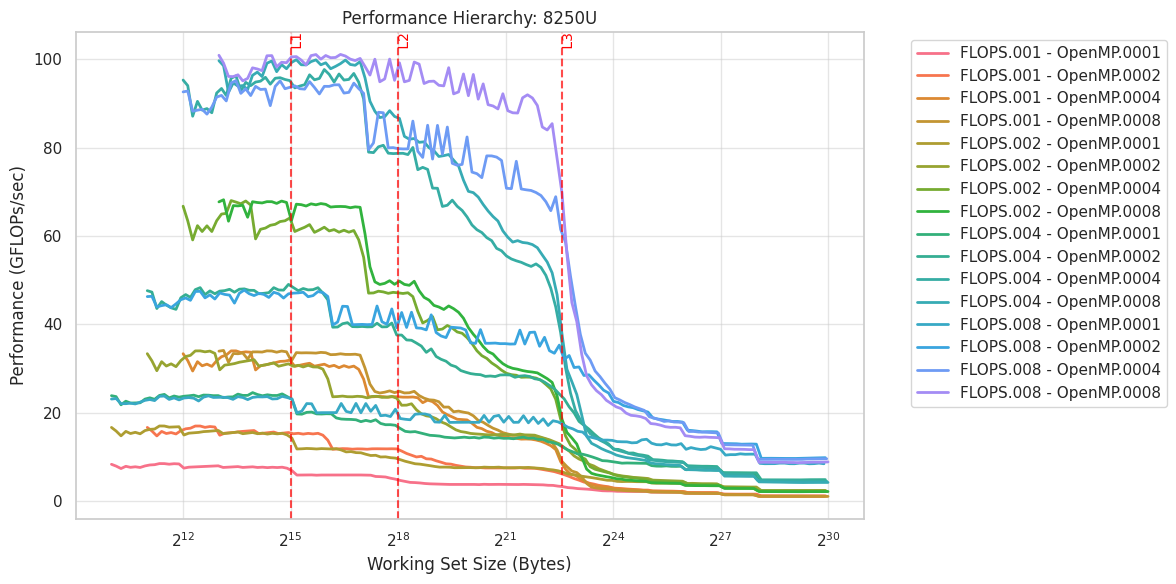

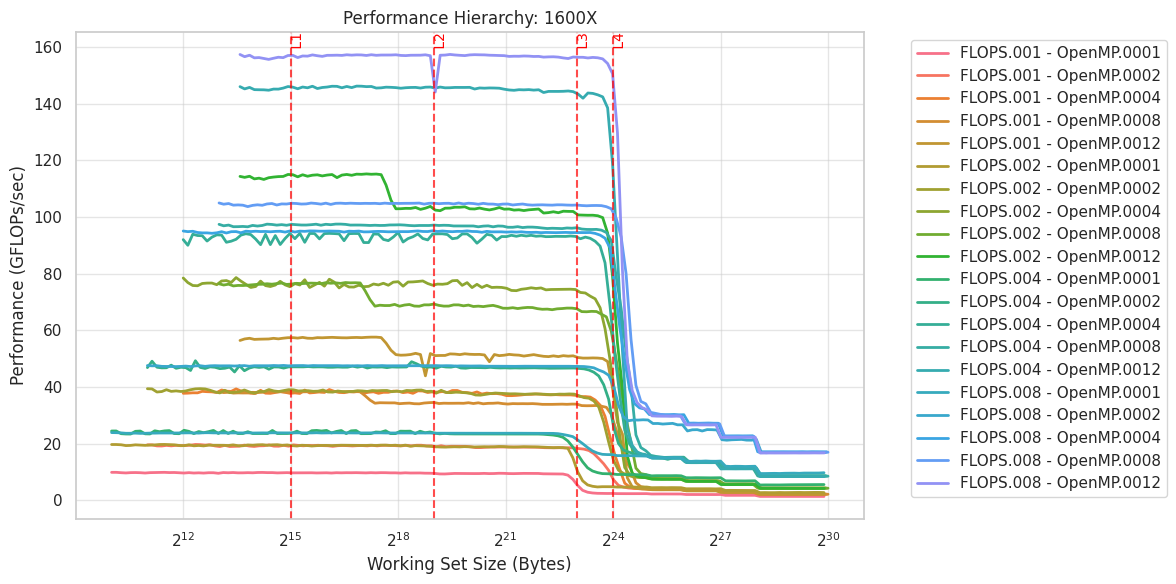

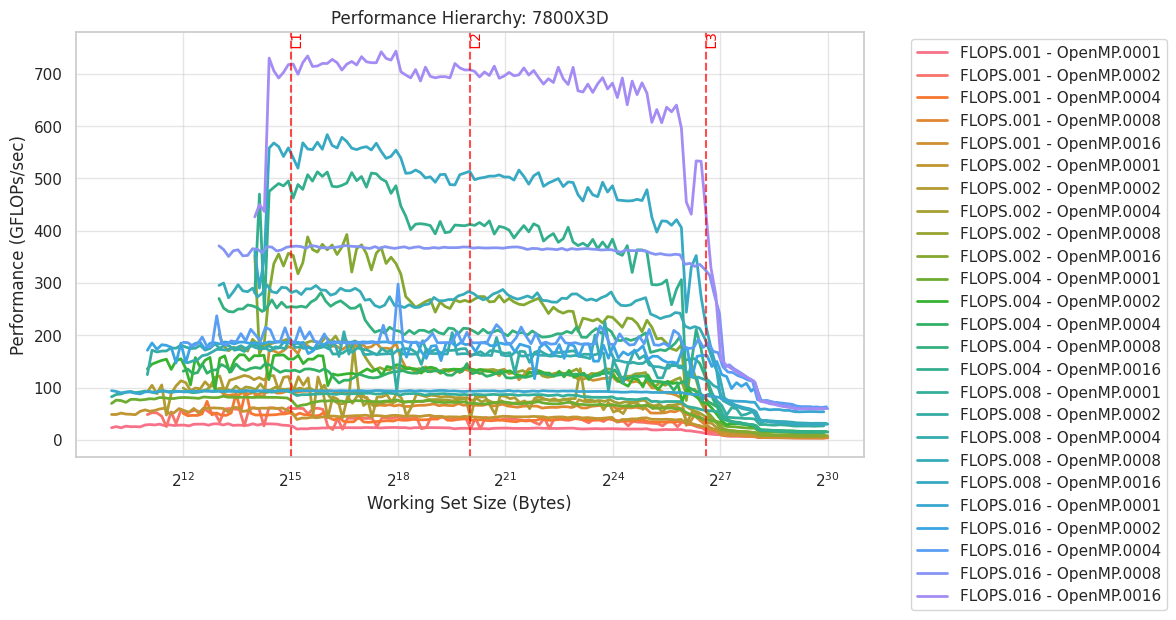

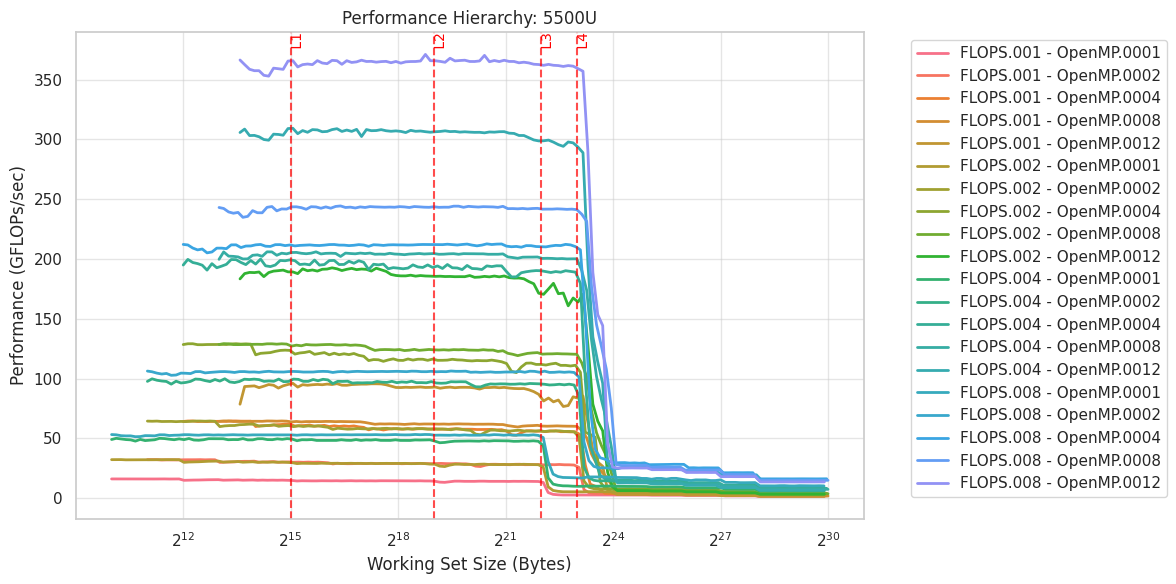

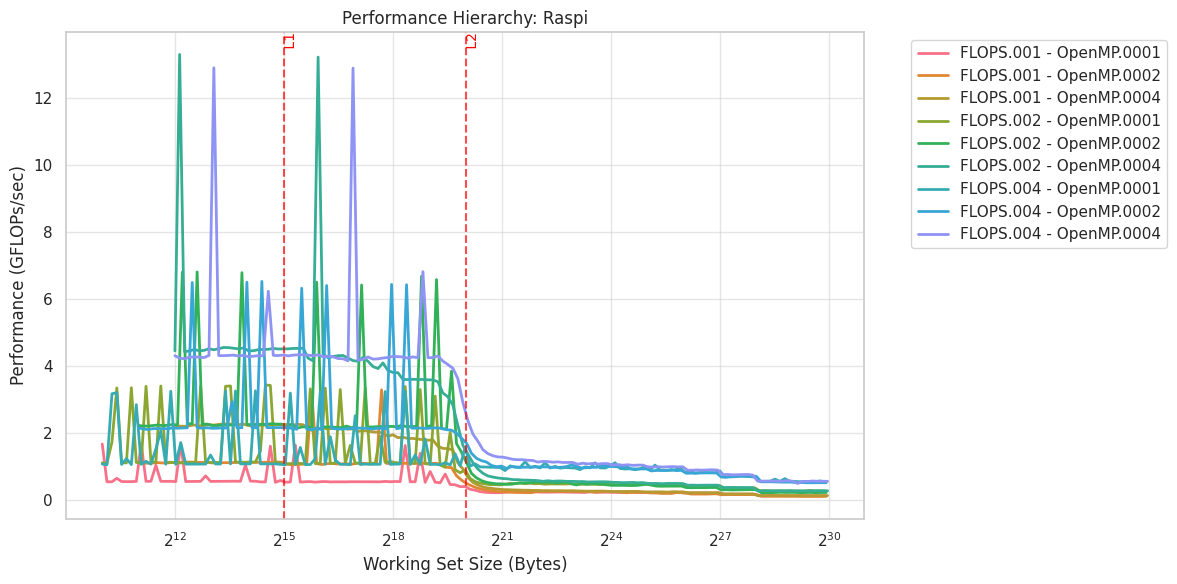

In [7]:
def plot_gflops_hierarchy(machine_name, run_name):
    # Filter raw data for this machine and run
    keys = [k for k in raw_data.keys() if k.startswith(f"{machine_name}/{run_name}/")]
    
    if not keys:
        return

    fig, ax = plt.subplots(figsize=(12, 6))
    
    keys.sort()
    colors = sns.color_palette("husl", int(len(keys)*1.3))
    
    for i, key in enumerate(keys):
        df = raw_data[key]
        parts = key.split('/')
        label = f"{parts[2]} - {parts[3]}"
        
        # Group by wkey and take max of GFLOP_sec_med
        best_gflops = df.groupby('wkey')['GFLOP_sec_med'].max().reset_index()
        
        ax.plot(best_gflops['wkey'], best_gflops['GFLOP_sec_med'], label=label, color=colors[i], linewidth=2)
        
    # Add cache lines
    if machine_name in caches:
        ymin, ymax = ax.get_ylim()
        for i, cache_size in enumerate(caches[machine_name]):
            ax.axvline(x=cache_size, color='red', linestyle='--', alpha=0.7)
            ax.text(cache_size, ymax, f' L{i+1}', rotation=90, verticalalignment='top', color='red', fontsize=10)

    ax.set_xscale('log', base=2)
    ax.set_xlabel('Working Set Size (Bytes)')
    ax.set_ylabel('Performance (GFLOPs/sec)')
    ax.set_title(f'Performance Hierarchy: {machine_name}')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, which="both", ls="-", alpha=0.5)
    plt.tight_layout()
    plt.show()

for machine in unique_machines:
    machine_runs = summary_df[summary_df['machine'] == machine]
    best_run_id = machine_runs.loc[machine_runs['max_gflops'].idxmax()]['run']
    plot_gflops_hierarchy(machine, best_run_id)

## Comparative Analysis
We compare the rooflines of different machines for specific memory levels (DRAM and L1) to understand relative performance characteristics.

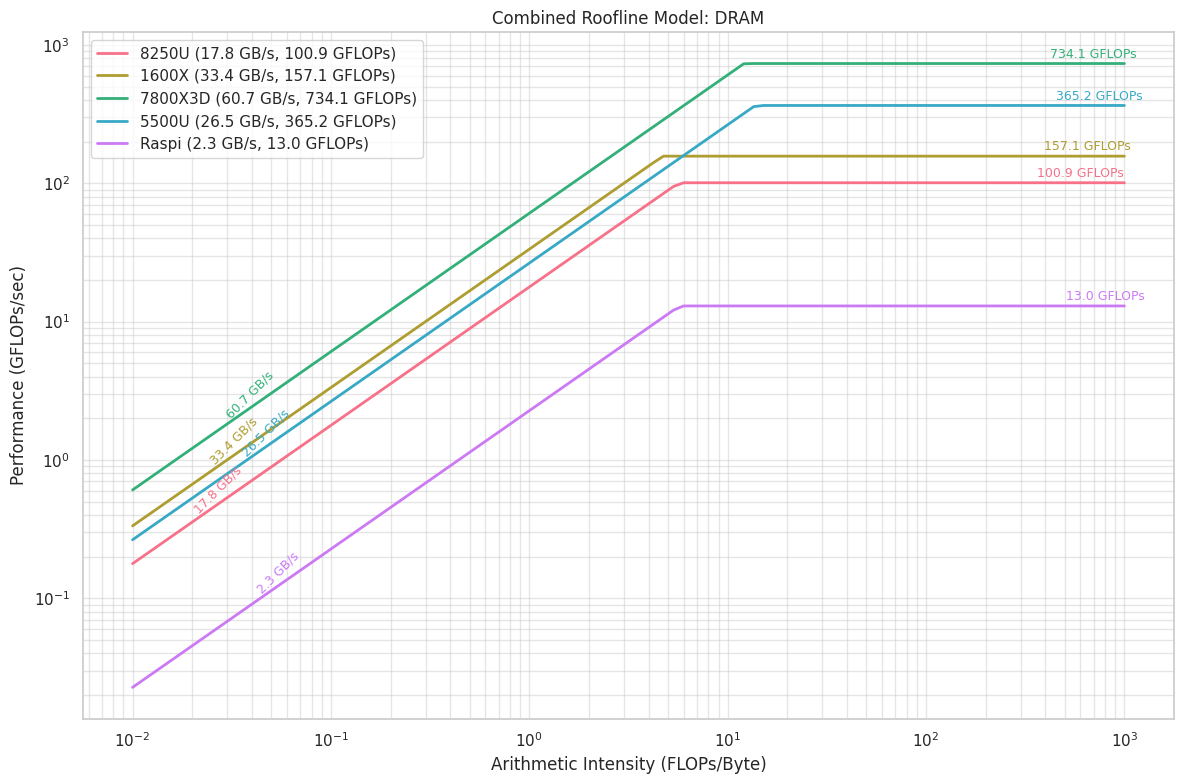

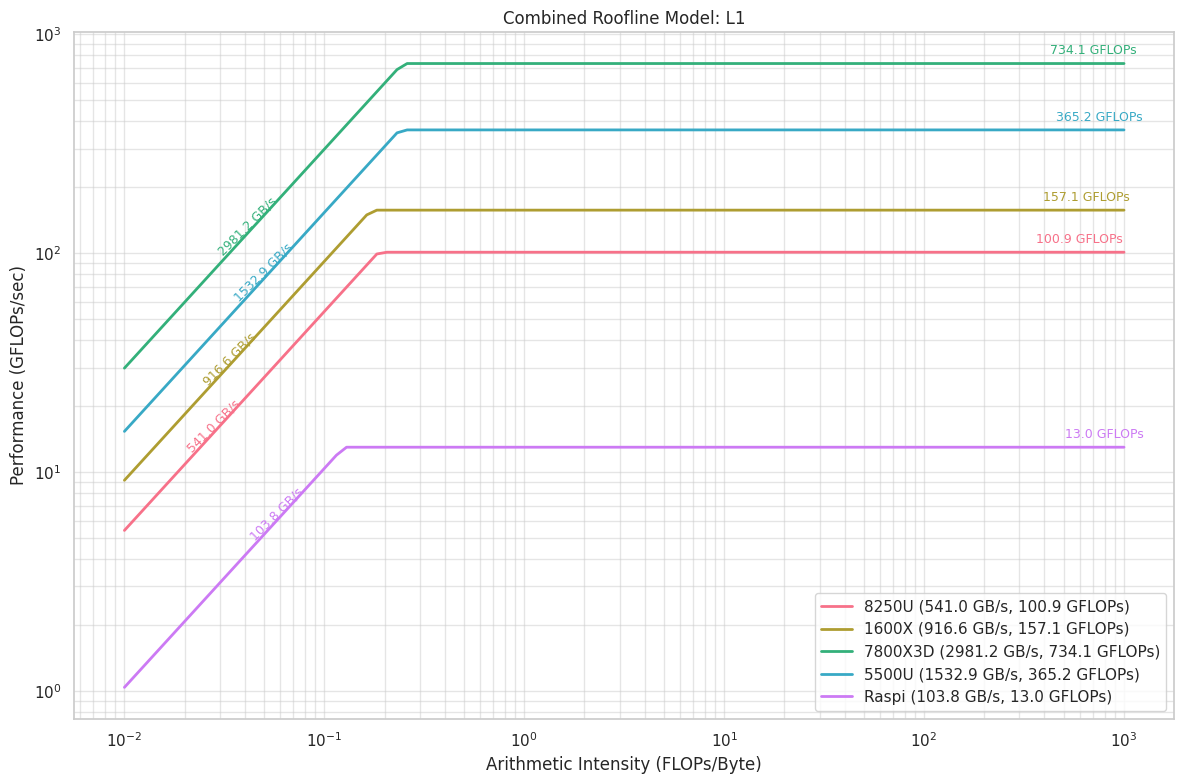

In [11]:
def plot_combined_roofline(memory_level_name, summary_df):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    ai_min = 0.01
    ai_max = 1000
    ai_points = np.logspace(np.log10(ai_min), np.log10(ai_max), 100)
    
    # Get unique machines
    unique_machines = summary_df['machine'].unique()
    colors = sns.color_palette("husl", len(unique_machines))
    
    for i, machine in enumerate(unique_machines):
        machine_runs = summary_df[summary_df['machine'] == machine]
        if machine_runs.empty:
            continue
            
        # Pick the run with highest GFLOPs
        best_run = machine_runs.loc[machine_runs['max_gflops'].idxmax()]
        
        gflops = best_run['max_gflops']
        
        # Find the bandwidth for the requested memory level
        bw = None
        # Exact match first
        if memory_level_name in best_run:
             bw = best_run[memory_level_name]
        else:
            # Fuzzy match
            for key in best_run.keys():
                if isinstance(key, str) and memory_level_name.lower() in key.lower():
                    bw = best_run[key]
                    break
        
        if bw is not None and not pd.isna(bw):
            y_points = np.minimum(gflops, bw * ai_points)
            ax.plot(ai_points, y_points, label=f"{machine} ({bw:.1f} GB/s, {gflops:.1f} GFLOPs)", color=colors[i], linewidth=2)
            
            # Annotate Bandwidth
            # Stagger AI slightly to avoid overlap
            ann_ai_bw = 0.02 * (1.2 ** i)
            if bw * ann_ai_bw < gflops:
                 ax.annotate(f"{bw:.1f} GB/s", xy=(ann_ai_bw, bw * ann_ai_bw), 
                             xytext=(ann_ai_bw, bw * ann_ai_bw * 1.1),
                             rotation=45, color=colors[i], fontsize=9, ha='left', va='bottom')
            
            # Annotate GFLOPs
            # Stagger AI slightly for GFLOPs too
            ann_ai_flops = ai_max * (0.6 + 0.05 * i)
            if ann_ai_flops > ai_max: ann_ai_flops = ai_max
            
            ax.annotate(f"{gflops:.1f} GFLOPs", xy=(ann_ai_flops, gflops), 
                        xytext=(ann_ai_flops, gflops * 1.1),
                        color=colors[i], fontsize=9, ha='center')

        else:
            print(f"Warning: {memory_level_name} bandwidth not found for {machine}")

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Arithmetic Intensity (FLOPs/Byte)')
    ax.set_ylabel('Performance (GFLOPs/sec)')
    ax.set_title(f'Combined Roofline Model: {memory_level_name}')
    ax.legend()
    #ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, which="both", ls="-", alpha=0.5)
    plt.tight_layout()
    plt.show()

# Call the function for DRAM and L1
plot_combined_roofline("DRAM", summary_df)
plot_combined_roofline("L1", summary_df)

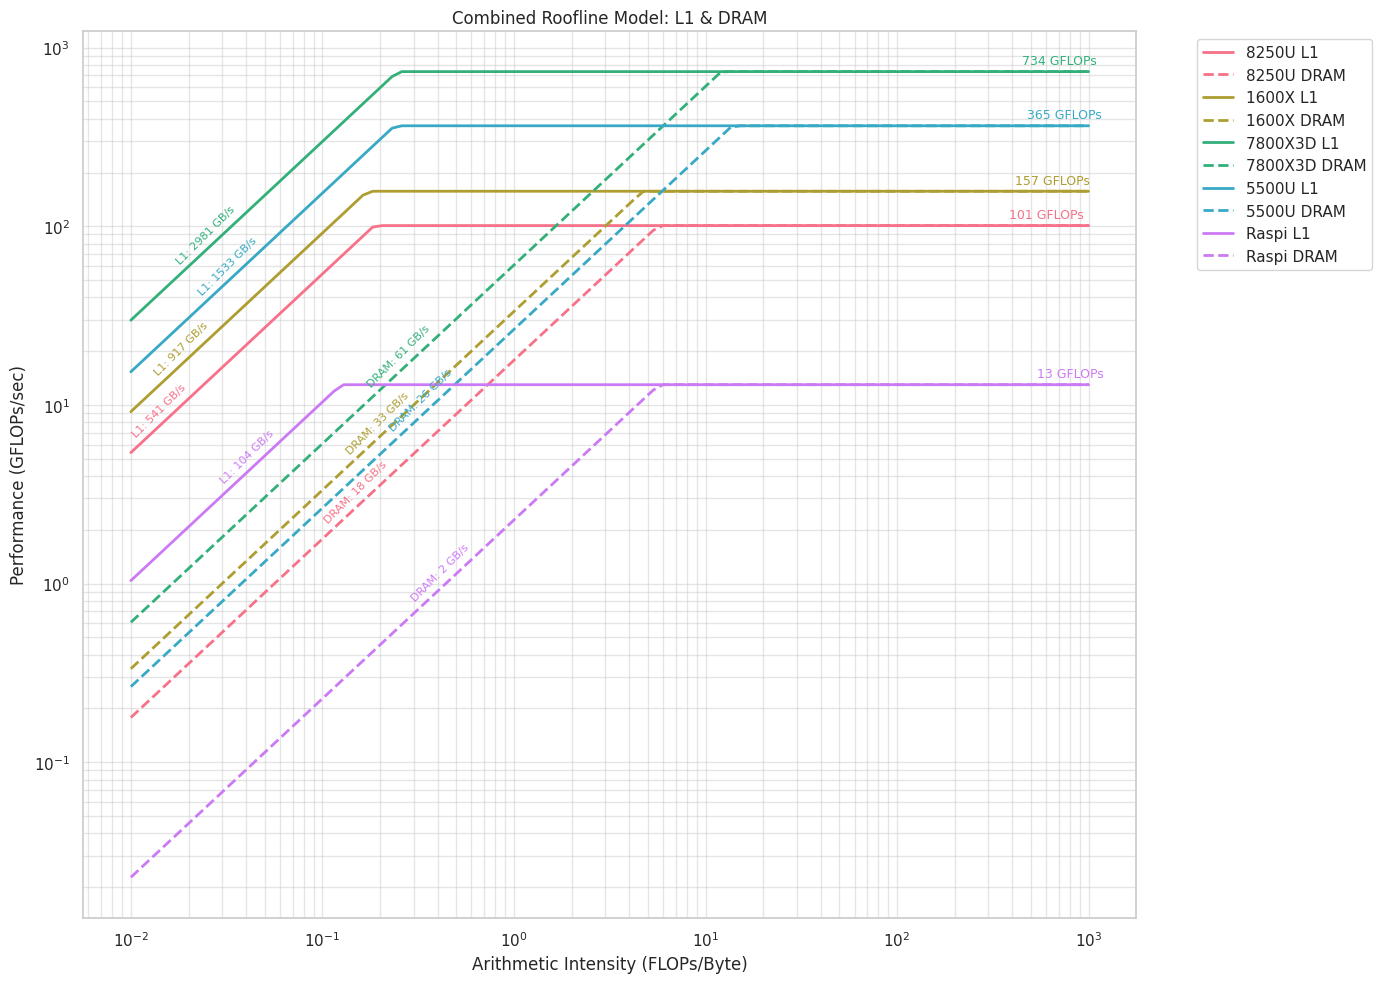

In [9]:
def plot_l1_dram_combined(summary_df):
    fig, ax = plt.subplots(figsize=(14, 10))
    
    ai_min = 0.01
    ai_max = 1000
    ai_points = np.logspace(np.log10(ai_min), np.log10(ai_max), 100)
    
    unique_machines = summary_df['machine'].unique()
    colors = sns.color_palette("husl", len(unique_machines))
    
    for i, machine in enumerate(unique_machines):
        machine_runs = summary_df[summary_df['machine'] == machine]
        if machine_runs.empty:
            continue
            
        best_run = machine_runs.loc[machine_runs['max_gflops'].idxmax()]
        gflops = best_run['max_gflops']
        
        # Find L1 and DRAM bandwidths
        bw_l1 = None
        bw_dram = None
        
        for key, val in best_run.items():
            if not isinstance(key, str): continue
            if "L1" in key: bw_l1 = val
            if "DRAM" in key: bw_dram = val
            
        # Plot L1 (Solid Line)
        if bw_l1 is not None:
            y_l1 = np.minimum(gflops, bw_l1 * ai_points)
            ax.plot(ai_points, y_l1, label=f"{machine} L1", color=colors[i], linestyle='-', linewidth=2)
            
            # Annotate L1
            ann_ai = 0.01 * (1.3 ** i)
            if bw_l1 * ann_ai < gflops:
                ax.annotate(f"L1: {bw_l1:.0f} GB/s", xy=(ann_ai, bw_l1 * ann_ai), 
                            xytext=(ann_ai, bw_l1 * ann_ai * 1.2),
                            rotation=45, color=colors[i], fontsize=8, ha='left', va='bottom')

        # Plot DRAM (Dashed Line)
        if bw_dram is not None:
            y_dram = np.minimum(gflops, bw_dram * ai_points)
            ax.plot(ai_points, y_dram, label=f"{machine} DRAM", color=colors[i], linestyle='--', linewidth=2)

            # Annotate DRAM
            ann_ai = 0.1 * (1.3 ** i) 
            if bw_dram * ann_ai < gflops:
                ax.annotate(f"DRAM: {bw_dram:.0f} GB/s", xy=(ann_ai, bw_dram * ann_ai), 
                            xytext=(ann_ai, bw_dram * ann_ai * 1.2),
                            rotation=45, color=colors[i], fontsize=8, ha='left', va='bottom')

        # Annotate Peak GFLOPs
        ann_ai_flops = ai_max * (0.6 + 0.05 * i)
        if ann_ai_flops > ai_max: ann_ai_flops = ai_max
        ax.annotate(f"{gflops:.0f} GFLOPs", xy=(ann_ai_flops, gflops), 
                    xytext=(ann_ai_flops, gflops * 1.1),
                    color=colors[i], fontsize=9, ha='center')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Arithmetic Intensity (FLOPs/Byte)')
    ax.set_ylabel('Performance (GFLOPs/sec)')
    ax.set_title('Combined Roofline Model: L1 & DRAM')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, which="both", ls="-", alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_l1_dram_combined(summary_df)

## Comparative Memory Hierarchy
Here we compare the memory hierarchy of all machines by plotting the bandwidth of their most performant configuration (highest FLOPS variant and highest thread count).

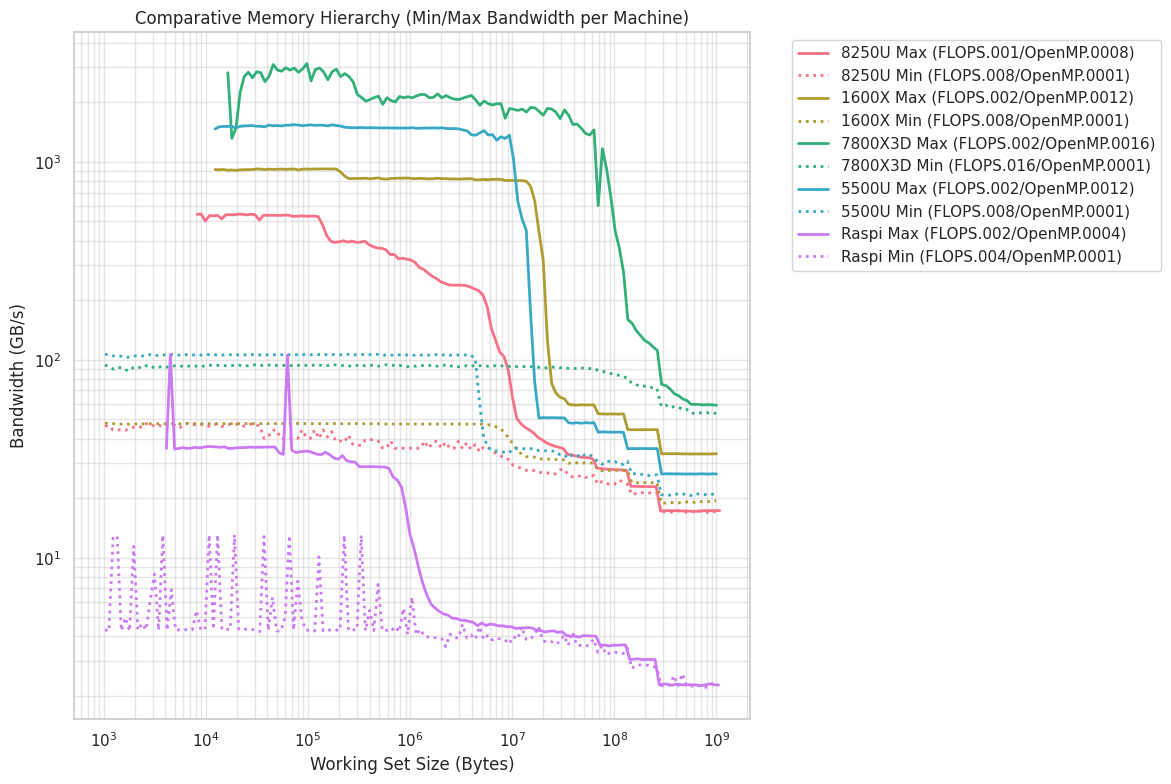

In [25]:
def plot_comparative_bandwidth_hierarchy(summary_df):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    unique_machines = summary_df['machine'].unique()
    colors = sns.color_palette("husl", len(unique_machines))
    
    for i, machine in enumerate(unique_machines):
        # Get all keys for this machine across all runs
        machine_keys = [k for k in raw_data.keys() if k.startswith(f"{machine}/")]
        
        if not machine_keys:
            continue
            
        # Find max bandwidth for each key to identify best/worst
        key_max_bw = []
        for k in machine_keys:
            df = raw_data[k]
            if df.empty or 'GB_sec_med' not in df.columns:
                continue
            # We use the peak bandwidth achieved in this trace as the metric
            max_bw = df['GB_sec_med'].max()
            key_max_bw.append((k, max_bw))
            
        if not key_max_bw:
            continue
            
        # Sort by max bandwidth
        key_max_bw.sort(key=lambda x: x[1])
        
        min_key, min_bw_val = key_max_bw[0]
        max_key, max_bw_val = key_max_bw[-1]
        
        # Plot Max Bandwidth Run (Solid)
        df_max = raw_data[max_key]
        best_bw_max = df_max.groupby('wkey')['GB_sec_med'].max().reset_index()
        parts_max = max_key.split('/')
        label_max = f"{machine} Max ({parts_max[2]}/{parts_max[3]})"
        ax.plot(best_bw_max['wkey'], best_bw_max['GB_sec_med'], label=label_max, color=colors[i], linewidth=2, linestyle='-')
        
        # Plot Min Bandwidth Run (Dotted)
        if min_key != max_key:
            df_min = raw_data[min_key]
            best_bw_min = df_min.groupby('wkey')['GB_sec_med'].max().reset_index()
            parts_min = min_key.split('/')
            label_min = f"{machine} Min ({parts_min[2]}/{parts_min[3]})"
            ax.plot(best_bw_min['wkey'], best_bw_min['GB_sec_med'], label=label_min, color=colors[i], linewidth=2, linestyle=':')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Working Set Size (Bytes)')
    ax.set_ylabel('Bandwidth (GB/s)')
    ax.set_title('Comparative Memory Hierarchy (Min/Max Bandwidth per Machine)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, which="both", ls="-", alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_comparative_bandwidth_hierarchy(summary_df)

## Conclusion
This notebook provides a comprehensive analysis of the ERT results.
- **Roofline Model**: Shows the theoretical peak performance and bandwidth limits.
- **Memory Hierarchy**: The Bandwidth vs. Working Set Size plots reveal the effective bandwidth at different cache levels (L1, L2, L3, DRAM).
- **Stability**: The Time vs. Trials plots help verify the reliability of the benchmark measurements.
- **Performance Hierarchy**: The GFLOPs vs. Working Set Size plots show how performance degrades as data moves further from the processor.
